### Importing Libraries

In [26]:
import importlib
import metrics, preprocessing, models.knn, models.logistic_regression, models.random_forest, models.gmm, models.dbscan, models.kmeans, models.mlp

importlib.reload(metrics)
importlib.reload(preprocessing)
importlib.reload(models.knn)
importlib.reload(models.logistic_regression)
importlib.reload(models.random_forest)
importlib.reload(models.gmm)
importlib.reload(models.dbscan)
importlib.reload(models.kmeans)
importlib.reload(models.mlp)

from preprocessing import Preprocessing
from models.knn import KNNModel
from models.logistic_regression import LogisticRegressionModel
from models.random_forest import RandomForestModel
from models.gmm import GMMModel
from models.dbscan import DBSCANModel
from models.kmeans import KMeansModel
from models.mlp import MLPModel
from keras import Sequential
from keras.layers import Input, Dense, Dropout
from keras.callbacks import EarlyStopping
from metrics import *

## Data Preprocessing

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


Shape of the dataset: (4601, 58)
<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_r

None

Duplicate Values: 391
spam
0    2531
1    1679
Name: count, dtype: int64
spam
0    0.601188
1    0.398812
Name: proportion, dtype: float64


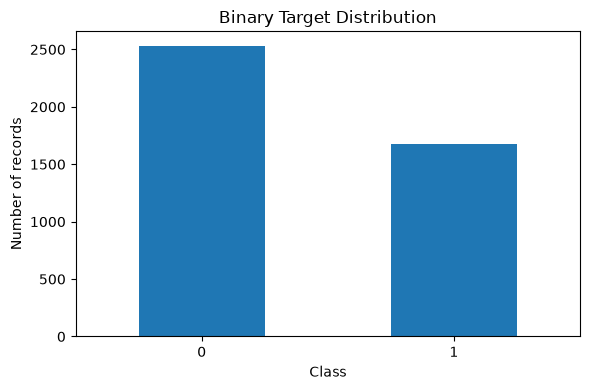

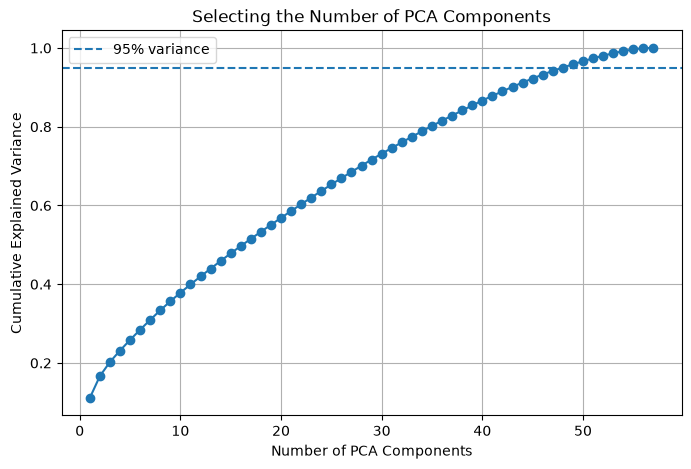

Original dimensions: (3368, 57)
Reduced dimensions: (3368, 48)
Total explained variance: 0.9504500037477235


In [2]:
prep = Preprocessing()

df = prep.ingest("Spam Detection .csv")
df, label_count = prep.cleaning(df)
prep.distribution(label_count)

X_train, X_test, y_train, y_test, class_names = prep.split(df)
X_train_scaled, X_test_scaled = prep.scaling(X_train, X_test)
X_train_pca, X_test_pca = prep.pca(X_train_scaled, X_test_scaled)

# Supervised

## K Nearest Neighbours 

Fitting 5 folds for each of 44 candidates, totalling 220 fits
Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best cross-validation accuracy: 0.904103597426819


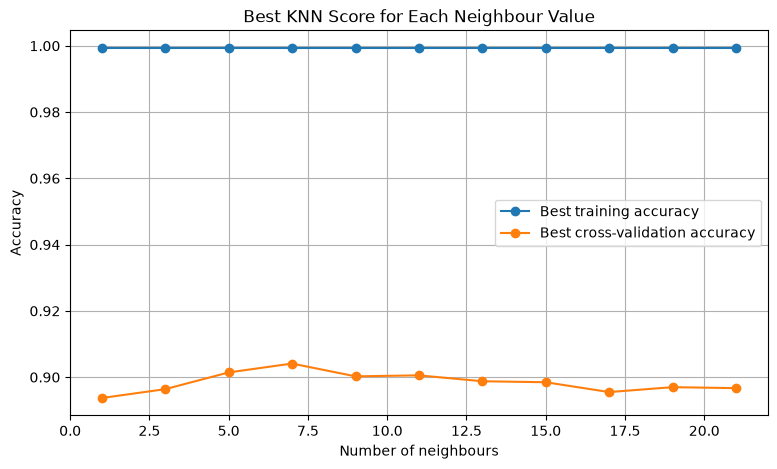

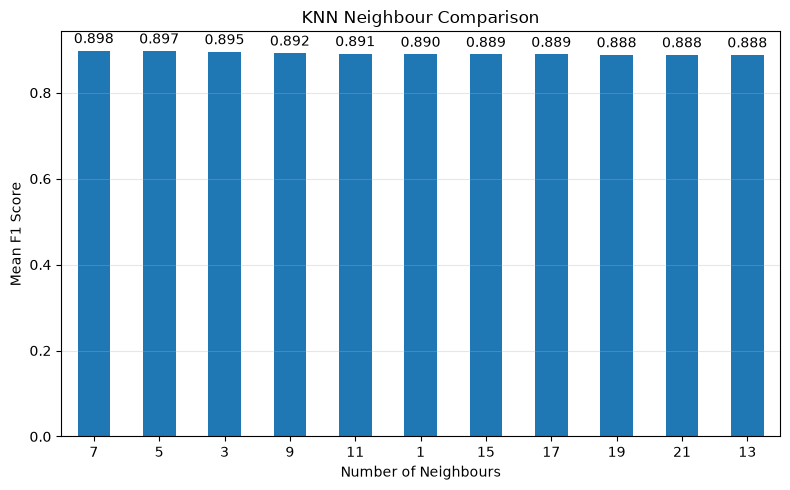

KNN test accuracy: 0.9085510688836105
              precision    recall  f1-score   support

    Not Spam       0.94      0.91      0.92       506
        Spam       0.86      0.91      0.89       336

    accuracy                           0.91       842
   macro avg       0.90      0.91      0.91       842
weighted avg       0.91      0.91      0.91       842



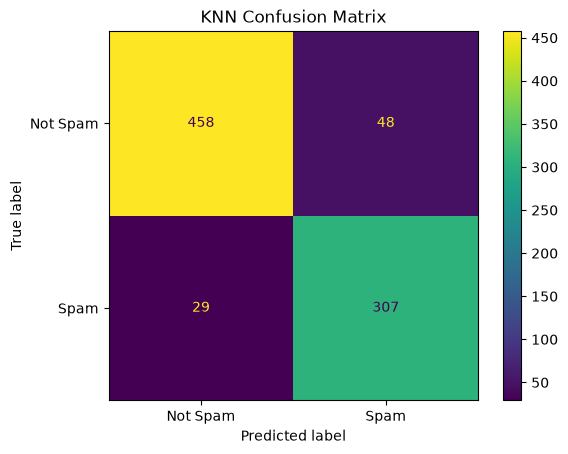

KNN ROC-AUC: 0.9617388951628081


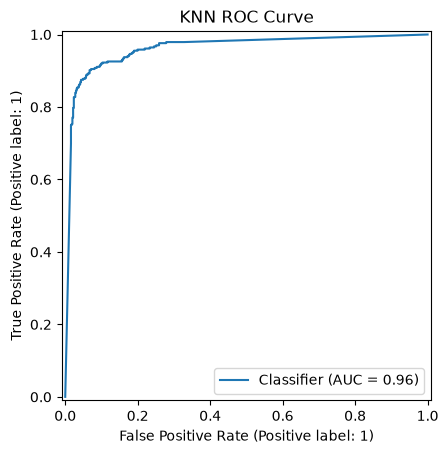

In [4]:
knn = KNNModel()

parameter_grid = {
    "knn__n_neighbors": list(range(1, 22, 2)), # Validating for neighbours 1 - 22
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_search_knn = knn.fit(X_train_pca, y_train, parameter_grid)

result = knn.best_model(grid_search_knn)
knn.plot_gridsearch_results(results=result)
best_knn, best_train_accuracy, best_validation_accuracy, y_test_pred, y_knn_prob = knn.evaluate_model(X_test_pca, grid_search_knn, results=result)

plot_gridsearch_results(
    grid_search_knn,
    parameter="knn__n_neighbors",
    title="KNN Neighbour Comparison",
    x_label="Number of Neighbours",
    score_label="Mean F1 Score"
)
check_classifier_fit(best_knn, X_train_pca, y_train, X_test_pca, y_test, "KNN")
KPIs(y_test, y_test_pred, y_knn_prob, "KNN")

## Logistic Regression

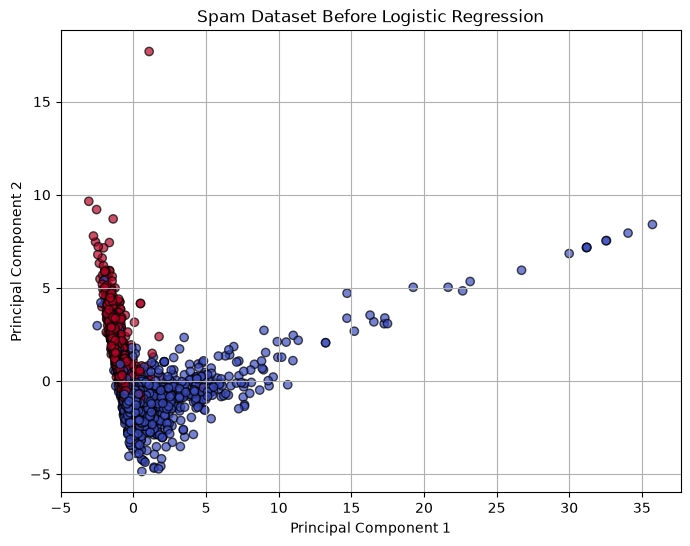

Fitting 5 folds for each of 60 candidates, totalling 300 fits
{'logistic__C': 0.1, 'logistic__l1_ratio': 1.0, 'logistic__solver': 'liblinear'}
0.8347026228574521


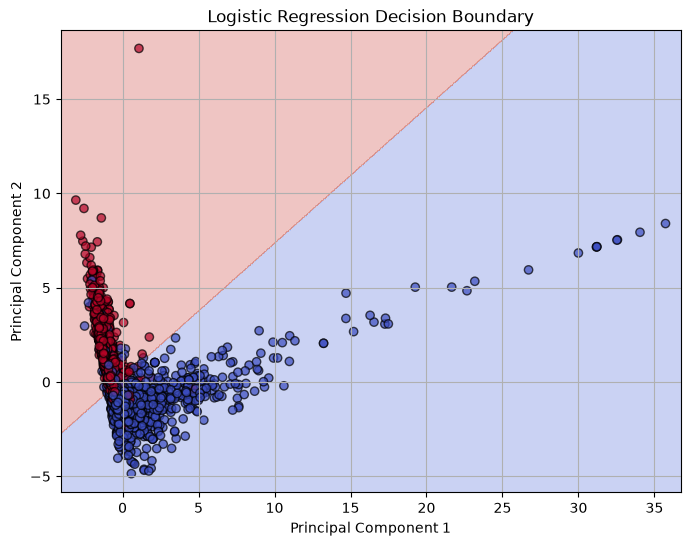

Logistic Regression test accuracy: 0.8942992874109263
              precision    recall  f1-score   support

    Not Spam       0.92      0.91      0.91       506
        Spam       0.86      0.88      0.87       336

    accuracy                           0.89       842
   macro avg       0.89      0.89      0.89       842
weighted avg       0.89      0.89      0.89       842



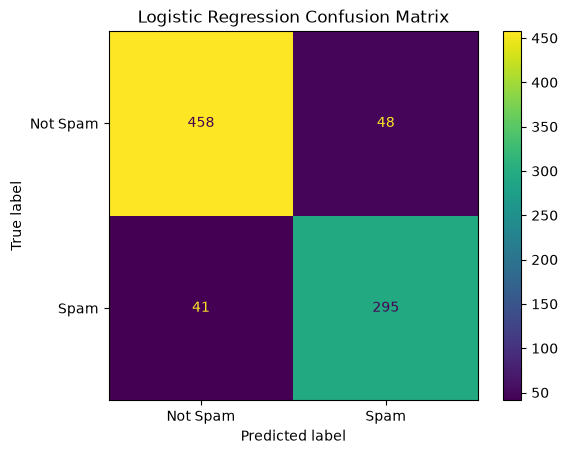

Logistic Regression ROC-AUC: 0.9500517598343685


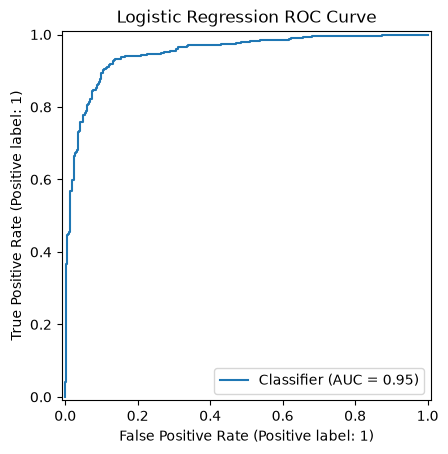

In [8]:
logistic_model = LogisticRegressionModel()

logistic_parameter_grid = [
    {
        "logistic__solver": ["liblinear"],
        "logistic__l1_ratio": [0.0, 1.0],
        "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "logistic__solver": ["lbfgs", "newton-cg", "newton-cholesky"],
        "logistic__l1_ratio": [0.0],
        "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "logistic__solver": ["saga"],
        "logistic__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
        "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100]
    },
]

logistic_model.eda(X_train_pca, y_train)
grid_search_logistic = logistic_model.fit(X_train_scaled, y_train, logistic_parameter_grid)
best_logistic = logistic_model.best_model(grid_search_logistic)
X_train_2d, X_test_2d = logistic_model.decision_boundary(best_logistic, X_train_scaled, y_train, X_test_scaled)


best_logistic_model = (grid_search_logistic.best_estimator_)
y_pred_logistic = (best_logistic_model.predict(X_test_scaled))
y_prob_logistic = best_logistic_model.predict_proba(X_test_scaled)[:, 1]
fitted_logistic = best_logistic.named_steps["logistic"]

check_classifier_fit(fitted_logistic, X_train_2d, y_train, X_test_2d, y_test, "Logistic Regression", )
KPIs(y_test, y_pred_logistic, y_prob_logistic, "Logistic Regression")

## Random Forest

In [ ]:
rf = RandomForestModel()

random_forest_parameters = {
    # "rfc__n_estimators": [100, 200, 300, 500],
    "rfc__n_estimators": [100, 200, 300],
    "rfc__max_depth": [None, 5, 10, 20],
    "rfc__min_samples_split": [2, 5, 10],
    "rfc__min_samples_leaf": [1, 2, 4],
    "rfc__max_features": ["sqrt", "log2"],
    "rfc__class_weight": [None, "balanced"]
}

grid_search_random_forest = rf.fit(X_train, y_train, random_forest_parameters)

best_random_forest = rf.best_model(grid_search_random_forest)
rf.importance(grid_search_random_forest, best_random_forest, X_train)

y_pred_random_forest = (best_random_forest.predict(X_test))
y_probability_random_forest = (best_random_forest.predict_proba(X_test)[:, 1])

check_classifier_fit(best_random_forest, X_train, y_train, X_test, y_test, "Random Forest", )
KPIs(y_test, y_pred_random_forest, y_probability_random_forest, "Random Forest")


Fitting 5 folds for each of 432 candidates, totalling 2160 fits


# Unsupervised

## Gausian Mixture Model

In [ ]:
gmm = GMMModel()

gmm_parameter_grid = {
    "gmm__n_components": list(range(2,16)),
    "gmm__covariance_type": ["full", "tied", "diag", "spherical"]
}

grid_search_gmm = gmm.fit(X_train_pca, gmm_parameter_grid)

best_gmm, train_clusters, test_clusters, X_train_plot = gmm.best_model(grid_search_gmm, X_train_pca, X_test_pca)
gmm.cluster_graphs(X_train_plot, train_clusters)
gmm.evaluate(best_gmm, X_train_pca, X_test_pca, y_train, y_test, train_clusters, test_clusters)

## DBSCAN

Best Parameters: {'eps': np.float64(4.25), 'min_samples': 5}
Best CV Silhouette: 0.2687975543284224
Number of clusters: 13
Coverage: 82.92755344418052
Noise: 17.07244655581948
Cluster Coverage: 82.93 %
Noise Percentage: 17.07 %


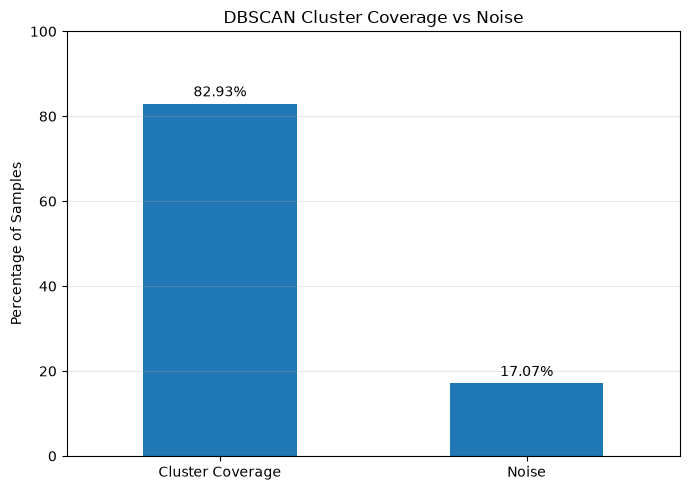

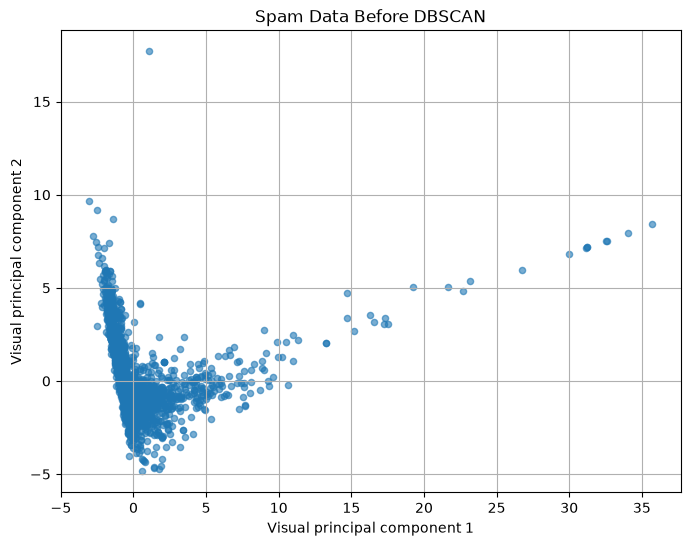

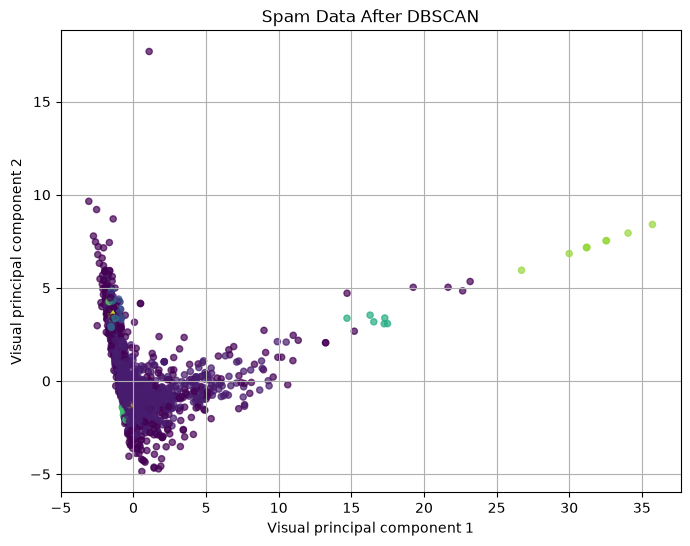

Cluster mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(1), np.int64(3): np.int64(1), np.int64(4): np.int64(1), np.int64(5): np.int64(1), np.int64(6): np.int64(0), np.int64(7): np.int64(0), np.int64(8): np.int64(0), np.int64(9): np.int64(1), np.int64(10): np.int64(0), np.int64(11): np.int64(1), np.int64(12): np.int64(0)}
Accuracy on non-noise records: 0.6297887576083064
DBSCAN Silhouette Score: 0.25599653578204373
Adjusted Rand Index: 0.017275645759411824
Normalized Mutual Information: 0.03175813094778732
Percentage evaluated: 82.92755344418052
DBSCAN test accuracy: 0.6297887576083064
              precision    recall  f1-score   support

    Not Spam       0.62      1.00      0.77      1707
        Spam       1.00      0.05      0.09      1086

    accuracy                           0.63      2793
   macro avg       0.81      0.52      0.43      2793
weighted avg       0.77      0.63      0.50      2793



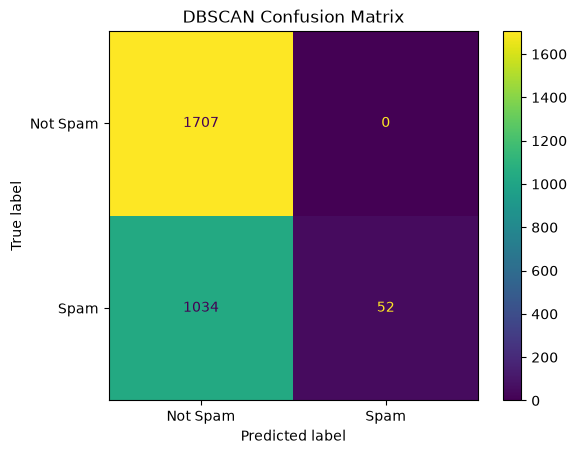

DBSCAN ROC-AUC: 0.5


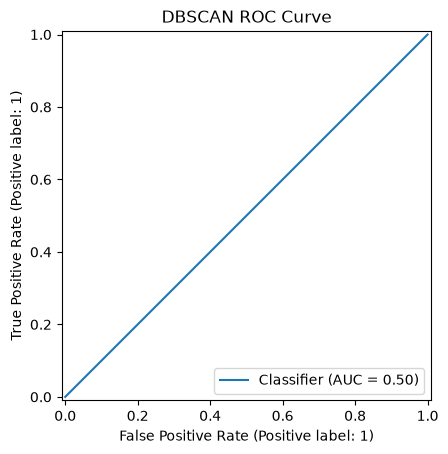

In [11]:
dbscan = DBSCANModel()

dbscan_parameters = {
    "eps": np.arange(0.5, 5.1, 0.25),
    "min_samples": [3, 5, 7, 10, 15, 20, 25, 30]
}

grid_search_dbscan = dbscan.fit(X_train_pca, dbscan_parameters, dbscan_scorer)
best_dbscan, best_clusters = dbscan.best_model(grid_search_dbscan, X_train_pca)
dbscan.evaluate_model(best_dbscan, best_clusters, X_train_pca)
actual_non_noise, mapped_predictions = dbscan.metrics(best_clusters, y_train, X_train_pca)

KPIs(actual_non_noise, mapped_predictions, best_clusters[actual_non_noise], "DBSCAN")

## Kmean Clustering

Best Parameters: {'algorithm': 'lloyd', 'max_iter': 300, 'n_clusters': 2, 'n_init': 10}
Best CV Silhouette: 0.6248112240242496
Number of clusters: 2
Best KMeans Inertia: 169360.9667687669
Best KMeans Silhouette: 0.6569539852074896


<Figure size 800x600 with 0 Axes>

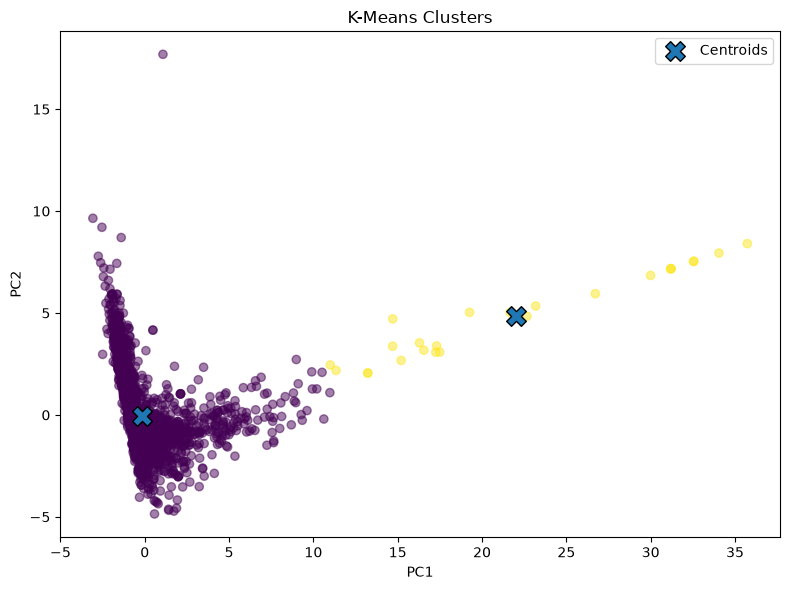

Cluster Mapping: {np.int32(0): np.int64(0), np.int32(1): np.int64(0)}
Predicted classes: (array([0]), array([842]))
Accuracy: 0.6009501187648456
Adjusted Rand Index: -0.0038733705504157404
Normalized Mutual Information: 0.008563717083374745
Silhouette Score: 0.6318727503859338


In [14]:
kmeans = KMeansModel()

kmeans_parameters = {
    "n_clusters": list(range(2, 11)),
    "n_init": [10, 20],
    "max_iter": [300, 500],
    "algorithm": ["lloyd","elkan"]
}

grid_search_kmeans = kmeans.fit(X_train_pca, kmeans_parameters, gmm_silhouette_scorer)
best_kmeans, best_k = kmeans.best_model(grid_search_kmeans, X_train_pca)
kmeans.cluster_graph(best_kmeans, X_train_pca)
kmeans.evaluate_model(best_kmeans, X_test_pca, y_test, X_train_pca, y_train)

# Deep Learning

## MLP

In [ ]:
mlp = MLPModel()
X_train_nn, X_test_nn, y_train_nn, y_test_nn = mlp.transform(X_train_pca, X_test_pca, y_train, y_test)

mlp_model = Sequential([
    Input(shape=(X_train_nn.shape[1],)),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(32, activation="relu"),
    Dropout(0.20),

    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = mlp.fit(X_train_nn, y_train_nn, early_stopping, mlp_model)

mlp.plot_training_history(history)
mlp.evaluate(mlp_model, history, X_test_nn, y_test_nn, y_test)

Training features: (3368, 48)
Testing features: (842, 48)
Training labels: (3368,)
Testing labels: (842,)
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7246 - auc: 0.7834 - loss: 0.5644 - precision: 0.7887 - recall: 0.4089 - val_accuracy: 0.9006 - val_auc: 0.9541 - val_loss: 0.3599 - val_precision: 0.9357 - val_recall: 0.8204
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8786 - auc: 0.9339 - loss: 0.3394 - precision: 0.8836 - recall: 0.7960 - val_accuracy: 0.9125 - val_auc: 0.9690 - val_loss: 0.2350 - val_precision: 0.9447 - val_recall: 0.8415
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8957 - auc: 0.9504 - loss: 0.2804 - precision: 0.8898 - recall: 0.8385 - val_accuracy: 0.9407 - val_auc: 0.9717 - val_loss: 0.2127 - val_precision: 0.9357 - val_recall: 0.9225
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9180 - auc: 0.9572 - loss: 0.2581 - precision: 0.9052 - recall: 0.8839 - val_accuracy: 0.9407 - val_auc: 0.972

## Autoencoder

### Convert the data to NumPy arrays

In [72]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
import tensorflow as tf

X_train_auto = np.asarray(X_train_pca).astype("float32")
X_test_auto = np.asarray(X_test_pca).astype("float32")

y_train_auto = np.asarray(y_train).astype(int)
y_test_auto = np.asarray(y_test).astype(int)

print("Training features:", X_train_auto.shape)
print("Testing features:", X_test_auto.shape)
print("Training labels:", y_train_auto.shape)
print("Testing labels:", y_test_auto.shape)

Training features: (3368, 48)
Testing features: (842, 48)
Training labels: (3368,)
Testing labels: (842,)


### Create training and validation sets

In [73]:
X_train_normal = X_train_auto[
    y_train_auto == 0
]

print("Normal training samples:", X_train_normal.shape)

X_normal_train, X_normal_validation = train_test_split(
    X_train_normal,
    test_size=0.20,
    random_state=42
)

print("Autoencoder training set:", X_normal_train.shape)
print("Autoencoder validation set:", X_normal_validation.shape)

Normal training samples: (2025, 48)
Autoencoder training set: (1620, 48)
Autoencoder validation set: (405, 48)


### Creating the Autoencoder

In [74]:
number_of_features = X_normal_train.shape[1]

autoencoder = Sequential([
    Input(shape=(number_of_features,)),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.10),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        8,
        activation="relu",
        name="bottleneck"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        number_of_features,
        activation="linear"
    )
])

### Compile and Training

In [75]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_autoencoder = autoencoder.fit(
    X_normal_train,
    X_normal_train,
    validation_data=(
        X_normal_validation,
        X_normal_validation
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    shuffle=True,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 48)             │         1,584 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,504 (17.59 KB)

 Trainable params: 4,504 (17.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2167 - val_loss: 0.8837
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1560 - val_loss: 0.8373
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0482 - val_loss: 0.7794
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9556 - val_loss: 0.7460
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9121 - val_loss: 0.7254
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8780 - val_loss: 0.7029
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8551 - val_loss: 0.6887
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8316 - val_loss: 0.6722
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8130 - val_loss: 0.6568
Epoch 10/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7891 - val_loss: 0.6410
Epoch 11/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7777 - val_loss: 0.6270
Epoch 12/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7

### Training and Validation loss Graph

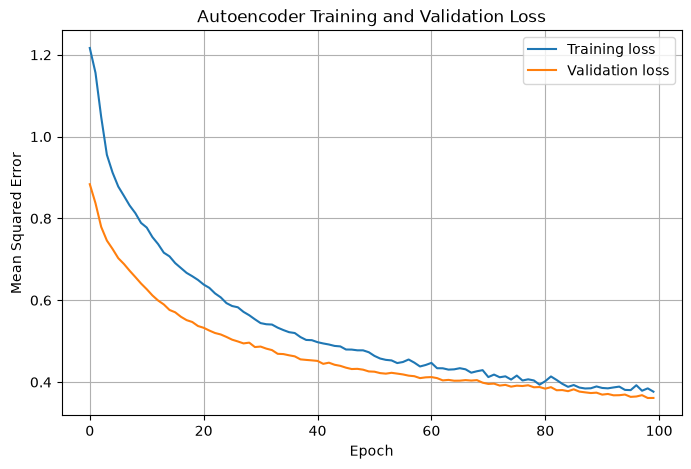

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_autoencoder.history["loss"],
    label="Training loss"
)

plt.plot(
    history_autoencoder.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Reconstruction Error Graph

Mean validation reconstruction error: 0.36108652
Maximum validation reconstruction error: 13.123822
Reconstruction-error threshold: 1.105004


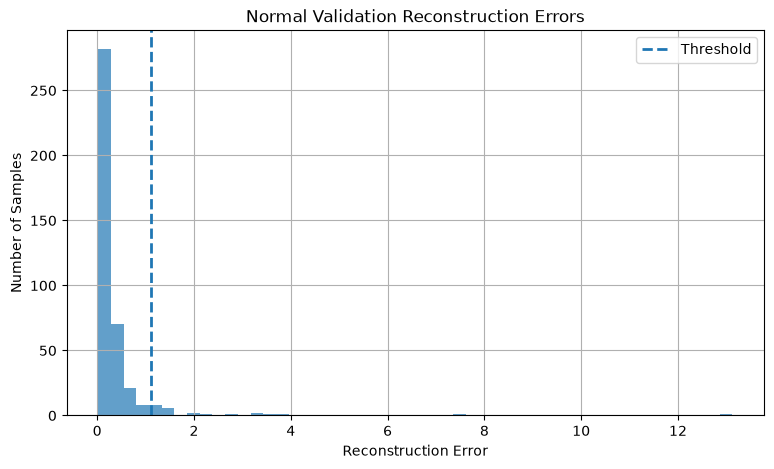

In [77]:
validation_reconstructed = autoencoder.predict(
    X_normal_validation,
    verbose=0
)

validation_errors = np.mean(
    np.square(
        X_normal_validation -
        validation_reconstructed
    ),
    axis=1
)

print("Mean validation reconstruction error:", validation_errors.mean())
print("Maximum validation reconstruction error:", validation_errors.max())

threshold = np.percentile(
    validation_errors,
    95
)

print("Reconstruction-error threshold:", threshold)

plt.figure(figsize=(9, 5))

plt.hist(
    validation_errors,
    bins=50,
    alpha=0.7
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Normal Validation Reconstruction Errors")
plt.legend()
plt.grid(True)
plt.show()

### KPIs

Autoencoder test accuracy: 0.6603325415676959
              precision    recall  f1-score   support

    Not Spam       0.65      0.95      0.77       506
        Spam       0.74      0.23      0.35       336

    accuracy                           0.66       842
   macro avg       0.69      0.59      0.56       842
weighted avg       0.69      0.66      0.60       842



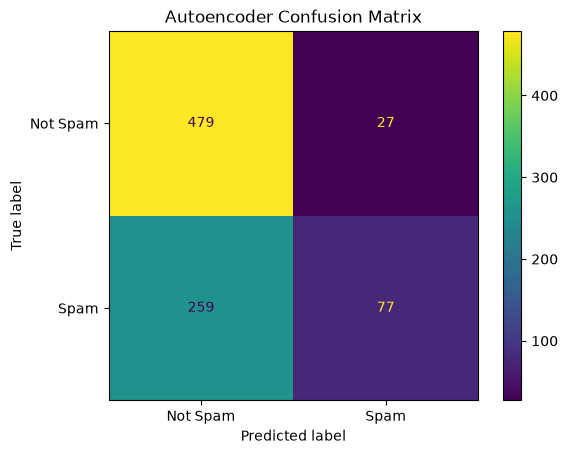

Autoencoder ROC-AUC: 0.7325781102955016


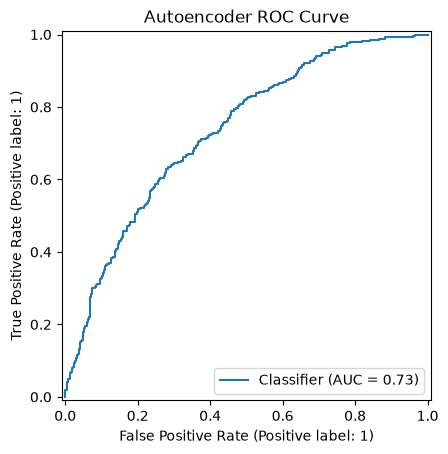

In [78]:
X_test_reconstructed = autoencoder.predict(
    X_test_auto,
    verbose=0
)

test_reconstruction_errors = np.mean(
    np.square(
        X_test_auto -
        X_test_reconstructed
    ),
    axis=1
)

y_pred_autoencoder = (
    test_reconstruction_errors > threshold
).astype(int)

y_probability_auto = np.mean(
    np.abs(X_test_pca - X_test_reconstructed),
    axis=1
)

KPIs(y_test, y_pred_autoencoder, y_probability_auto, "Autoencoder")

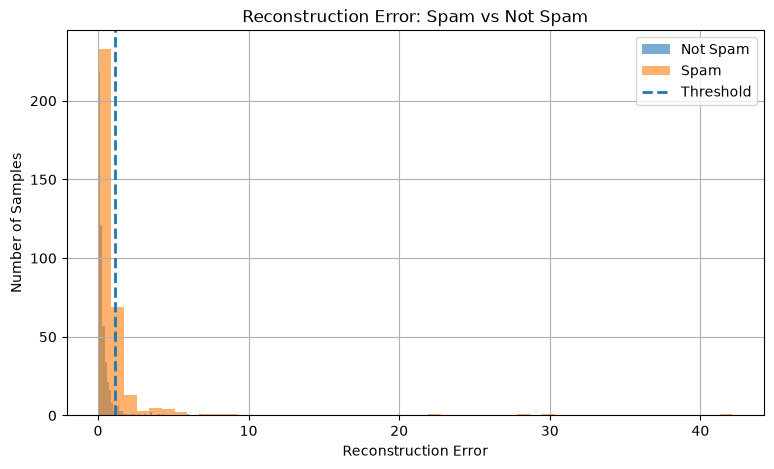

In [79]:
error_dataframe = pd.DataFrame({
    "Reconstruction Error": test_reconstruction_errors,
    "Actual Label": y_test_auto
})

not_spam_errors = error_dataframe[
    error_dataframe["Actual Label"] == 0
]["Reconstruction Error"]

spam_errors = error_dataframe[
    error_dataframe["Actual Label"] == 1
]["Reconstruction Error"]

plt.figure(figsize=(9, 5))

plt.hist(
    not_spam_errors,
    bins=50,
    alpha=0.6,
    label="Not Spam"
)

plt.hist(
    spam_errors,
    bins=50,
    alpha=0.6,
    label="Spam"
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Reconstruction Error: Spam vs Not Spam")
plt.legend()
plt.grid(True)
plt.show()

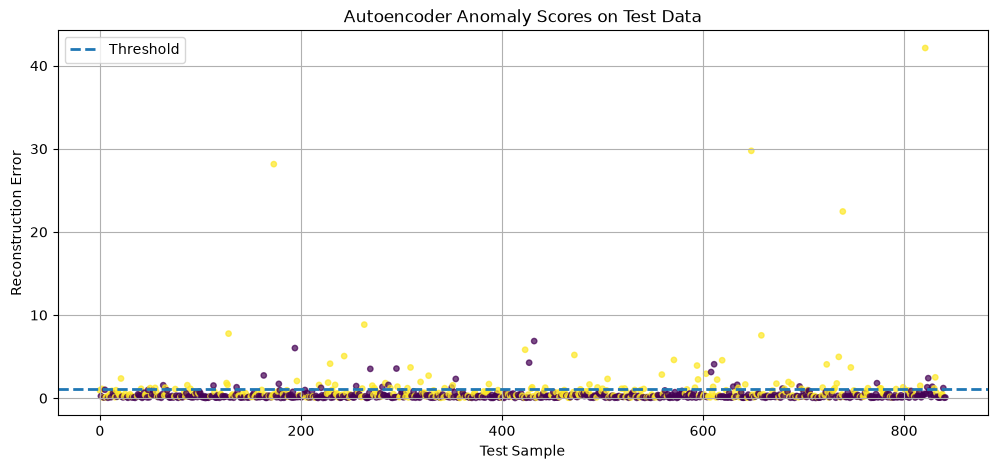

In [80]:
plt.figure(figsize=(12, 5))

plt.scatter(
    range(len(test_reconstruction_errors)),
    test_reconstruction_errors,
    c=y_test_auto,
    s=15,
    alpha=0.7
)

plt.axhline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlabel("Test Sample")
plt.ylabel("Reconstruction Error")
plt.title("Autoencoder Anomaly Scores on Test Data")
plt.legend()
plt.grid(True)
plt.show()

In [81]:
threshold_percentiles = [
    90,
    92,
    95,
    97,
    99
]

threshold_results = []

for percentile in threshold_percentiles:

    current_threshold = np.percentile(
        validation_errors,
        percentile
    )

    current_predictions = (
        test_reconstruction_errors >
        current_threshold
    ).astype(int)

    report = classification_report(
        y_test_auto,
        current_predictions,
        labels=[0, 1],
        output_dict=True,
        zero_division=0
    )

    threshold_results.append({
        "Percentile": percentile,
        "Threshold": current_threshold,
        "Accuracy": accuracy_score(
            y_test_auto,
            current_predictions
        ),
        "Spam Precision": report["1"]["precision"],
        "Spam Recall": report["1"]["recall"],
        "Spam F1": report["1"]["f1-score"]
    })

threshold_results = pd.DataFrame(
    threshold_results
)

print(threshold_results)

   Percentile  Threshold  Accuracy  Spam Precision  Spam Recall   Spam F1
0          90   0.666795  0.691211        0.702128     0.392857  0.503817
1          92   0.791915  0.684086        0.724359     0.336310  0.459350
2          95   1.105004  0.660333        0.740385     0.229167  0.350000
3          97   1.430409  0.634204        0.725806     0.133929  0.226131
4          99   3.393423  0.615202        0.750000     0.053571  0.100000


# Summary

In [82]:
def calculate_model_metrics(
    model_name,
    model_type,
    y_true,
    y_pred,
    y_score=None
):
    """
    Calculates binary spam-detection metrics.

    y_score should contain probabilities or anomaly scores.
    It is optional because some models do not provide them.
    """

    results = {
        "Model": model_name,
        "Category": model_type,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Spam Precision": precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "Spam Recall": recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "Spam F1": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        )
    }

    if y_score is not None:
        results["ROC-AUC"] = roc_auc_score(
            y_true,
            y_score
        )
    else:
        results["ROC-AUC"] = np.nan

    return results

In [83]:
# KNN
y_test_pred

# Logistic Regression
y_pred_logistic
y_prob_logistic

# GMM
y_pred_gmm

# DBSCAN, after excluding noise
actual_non_noise
mapped_predictions

# MLP
y_pred_mlp
y_probability_mlp

# Autoencoder
y_pred_autoencoder
test_reconstruction_errors

array([9.45287228e-01, 2.47406587e-01, 1.11806595e+00, 8.04641619e-02,
       7.91054592e-02, 1.01088619e+00, 1.09953731e-01, 1.87170327e-01,
       4.89064455e-02, 2.36850336e-01, 4.69082505e-01, 1.10085852e-01,
       8.79989624e-01, 5.78495264e-01, 3.83260816e-01, 1.20662481e-01,
       9.60610449e-01, 1.67623281e-01, 6.63436651e-01, 4.83660221e-01,
       2.35840604e-01, 2.36729455e+00, 1.95563316e-01, 9.16523561e-02,
       1.90577924e-01, 5.18921196e-01, 1.91677198e-01, 1.24357313e-01,
       5.06882854e-02, 2.90836930e-01, 4.66210753e-01, 1.74617872e-01,
       7.58424997e-02, 1.87431976e-01, 1.02066197e-01, 3.99128161e-02,
       1.68143392e-01, 2.42877141e-01, 4.81110662e-01, 3.50543231e-01,
       1.87309816e-01, 1.13334846e+00, 4.53457087e-02, 1.49765179e-01,
       6.57858610e-01, 3.73735428e-01, 4.96178716e-01, 9.03099179e-02,
       9.90349591e-01, 9.57723632e-02, 1.21415937e+00, 3.17276388e-01,
       4.92385000e-01, 9.29856956e-01, 3.05720210e-01, 1.23792648e+00,
      

In [84]:
y_probability_knn = best_knn.predict_proba(
    X_test_pca
)[:, 1]

all_model_results = []

all_model_results.append(
    calculate_model_metrics(
        model_name="KNN",
        model_type="Supervised",
        y_true=y_test,
        y_pred=y_test_pred,
        y_score=y_probability_knn
    )
)

all_model_results.append(
    calculate_model_metrics(
        model_name="Logistic Regression",
        model_type="Supervised",
        y_true=y_test,
        y_pred=y_pred_logistic,
        y_score=y_prob_logistic
    )
)

all_model_results.append(
    calculate_model_metrics(
        model_name="Random Forest",
        model_type="Supervised",
        y_true=y_test,
        y_pred=y_pred_random_forest,
        y_score=y_probability_random_forest
    )
)



all_model_results.append(
    calculate_model_metrics(
        model_name="MLP",
        model_type="Deep Learning",
        y_true=y_test_nn.astype(int),
        y_pred=y_pred_mlp,
        y_score=y_probability_mlp
    )
)

all_model_results.append(
    calculate_model_metrics(
        model_name="Autoencoder",
        model_type="Deep Learning",
        y_true=y_test_auto,
        y_pred=y_pred_autoencoder,
        y_score=test_reconstruction_errors
    )
)

model_comparison = pd.DataFrame(
    all_model_results
)

metric_columns = [
    "Accuracy",
    "Spam Precision",
    "Spam Recall",
    "Spam F1",
    "ROC-AUC"
]

model_comparison[metric_columns] = (
    model_comparison[metric_columns].round(4)
)

model_comparison

,Model,Category,Accuracy,Spam Precision,Spam Recall,Spam F1,ROC-AUC
0,KNN,Supervised,0.9086,0.8648,0.9137,0.8886,0.9617
1,Logistic Regression,Supervised,0.8943,0.8601,0.8780,0.8689,0.9501
2,Random Forest,Supervised,0.9406,0.9231,0.9286,0.9258,0.9897
3,MLP,Deep Learning,0.9311,0.9137,0.9137,0.9137,0.9788
4,Autoencoder,Deep Learning,0.6603,0.7404,0.2292,0.3500,0.7363


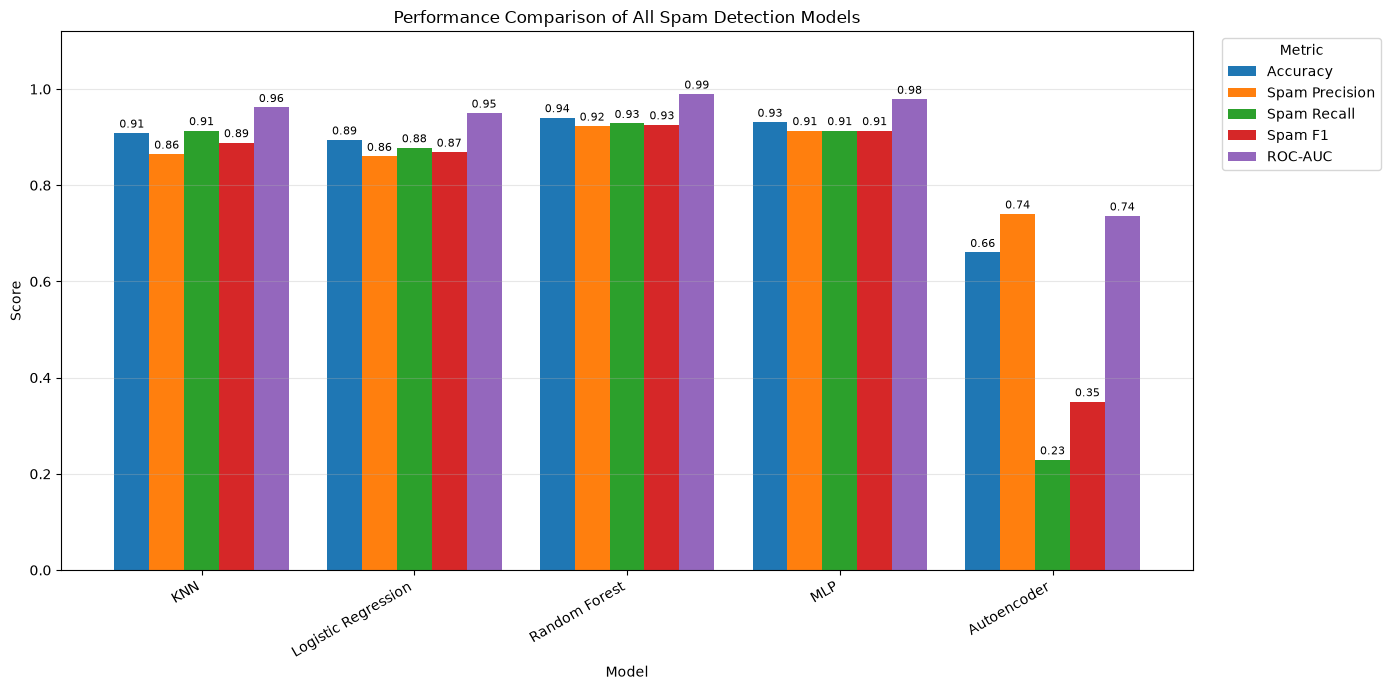

In [85]:
plot_data = model_comparison.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Spam Precision",
        "Spam Recall",
        "Spam F1",
        "ROC-AUC"
    ]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.82
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=8,
        padding=2
    )

plt.title(
    "Performance Comparison of All Spam Detection Models"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.12)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

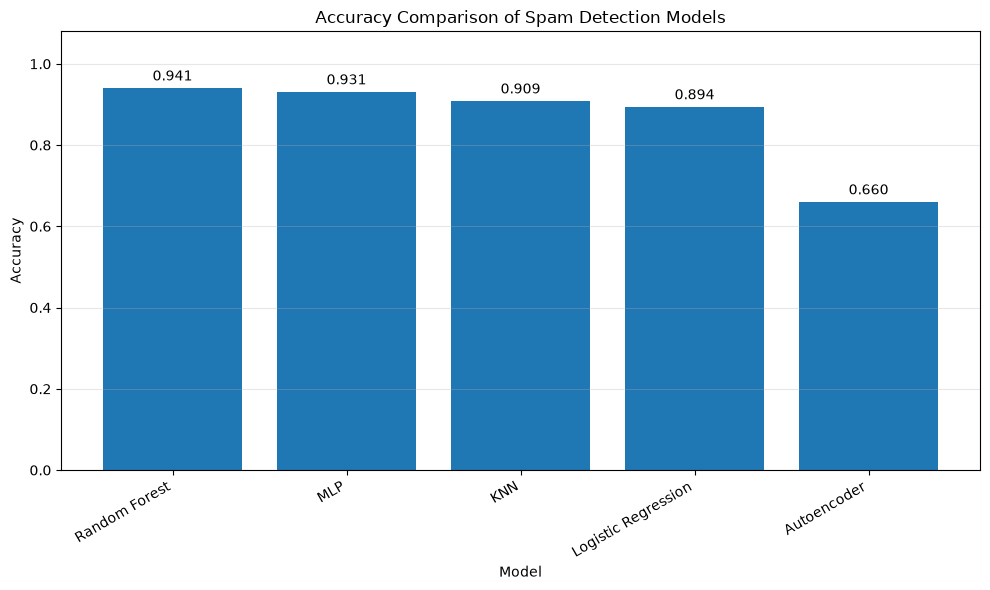

In [86]:
accuracy_results = model_comparison.sort_values(
    "Accuracy",
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    accuracy_results["Model"],
    accuracy_results["Accuracy"]
)

plt.bar_label(
    bars,
    fmt="%.3f",
    padding=3
)

plt.title(
    "Accuracy Comparison of Spam Detection Models"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.08)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

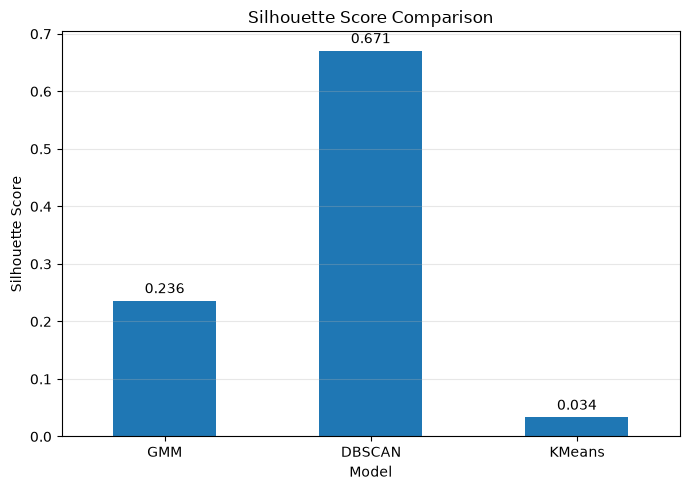

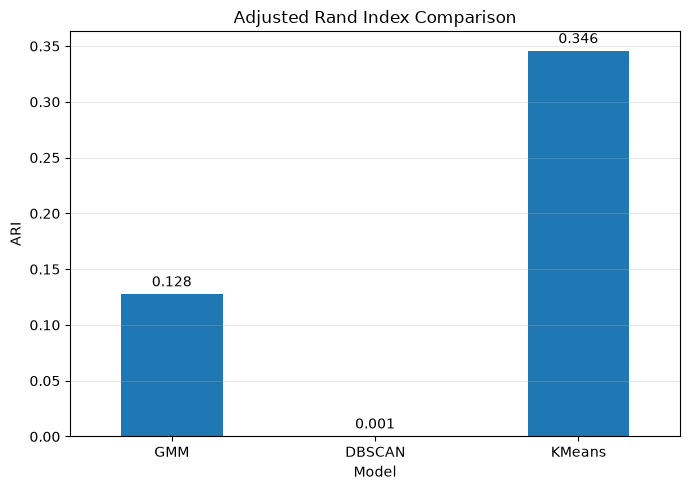

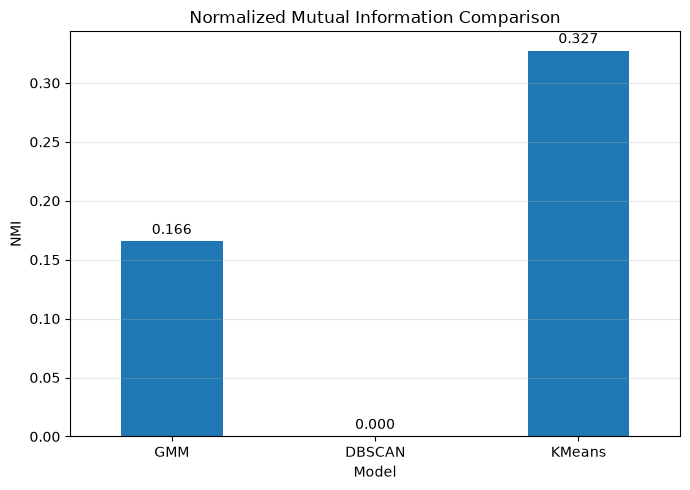

In [87]:
dbscan_coverage = (
    len(actual_non_noise) /
    len(y_train)
)

unsupervised_results = pd.DataFrame({
    "Model": [
        "GMM",
        "DBSCAN",
        "KMeans"
    ],

    "Silhouette Score": [
        gmm_silhouette_score,
        dbscan_silhouette,
        kmeans_silhouette
    ],

    "Adjusted Rand Index": [
        gmm_ari,
        dbscan_ari,
        kmeans_ari
    ],

    "Normalized Mutual Information": [
        gmm_nmi,
        dbscan_nmi,
        kmeans_nmi
    ],

    "Coverage": [
        1.0,
        dbscan_coverage,
        1.0
    ]
})

metric_columns = [
    "Silhouette Score",
    "Adjusted Rand Index",
    "Normalized Mutual Information",
    "Coverage"
]

for column in metric_columns:
    unsupervised_results[column] = pd.to_numeric(
        unsupervised_results[column],
        errors="coerce"
    )
    
def plot_metric(metric_name, y_label):

    ax = unsupervised_results.plot(
        x="Model",
        y=metric_name,
        kind="bar",
        figsize=(7, 5),
        legend=False
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=3
        )

    plt.title(f"{metric_name} Comparison")
    plt.xlabel("Model")
    plt.ylabel(y_label)
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric("Silhouette Score", "Silhouette Score")
plot_metric("Adjusted Rand Index","ARI")
plot_metric("Normalized Mutual Information","NMI")